# Task 4: Clustering - Gaussian Mixture Models

Libraries:

In [66]:
import joblib
import copy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

Load data:

In [67]:
X_clustering = pd.read_csv("../data/03_selected/clustering_features.csv")
X_clustering.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   thalach   303 non-null    int64  
 1   oldpeak   303 non-null    float64
 2   ca        303 non-null    int64  
 3   cp_4      303 non-null    bool   
 4   is_exang  303 non-null    bool   
 5   thal_3    303 non-null    bool   
 6   thal_7    303 non-null    bool   
dtypes: bool(4), float64(1), int64(2)
memory usage: 8.4 KB


In [68]:
pca = joblib.load("../data/03_selected/pca_model.pkl")
X_pca = pd.read_csv("../data/03_selected/pca_space.csv")
X_pca.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     303 non-null    float64
 1   PC2     303 non-null    float64
 2   PC3     303 non-null    float64
 3   PC4     303 non-null    float64
 4   PC5     303 non-null    float64
 5   PC6     303 non-null    float64
 6   PC7     303 non-null    float64
 7   PC8     303 non-null    float64
 8   PC9     303 non-null    float64
 9   PC10    303 non-null    float64
 10  PC11    303 non-null    float64
 11  PC12    303 non-null    float64
 12  PC13    303 non-null    float64
 13  PC14    303 non-null    float64
 14  PC15    303 non-null    float64
 15  PC16    303 non-null    float64
 16  PC17    303 non-null    float64
 17  PC18    303 non-null    float64
 18  PC19    303 non-null    float64
 19  PC20    303 non-null    float64
 20  PC21    303 non-null    float64
 21  PC22    303 non-null    float64
dtypes: float64(22

C:\Users\hidal\AppData\Local\Temp\ipykernel_14724\1801078437.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


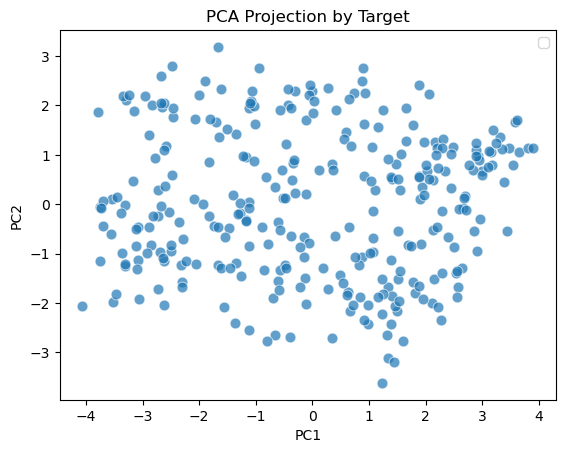

In [69]:
plt.figure()

# Plot each class separately
sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"],
    s = 60,
    alpha = 0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection by Target")
plt.legend()
plt.show()

### 4.1 Fit GGMs with a varying number of components (2 to 10)

In [70]:
n_components_range = range(2,11)

bic_scores = []
aic_scores = []

for n_components in n_components_range:
    # Set up model
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full', # each cluster its own elliptical shape
        init_params='random', # initialize weights randomly (defaul = KMeans)
        random_state=42 # fix the random seed
    )

    # Fit the model
    gmm.fit(X_clustering)

    # Compute and save BIC and AIC
    bic_scores.append(gmm.bic(X_clustering))
    aic_scores.append(gmm.aic(X_clustering))

### 4.2 Use BIC or AIC to select the optimal number of components

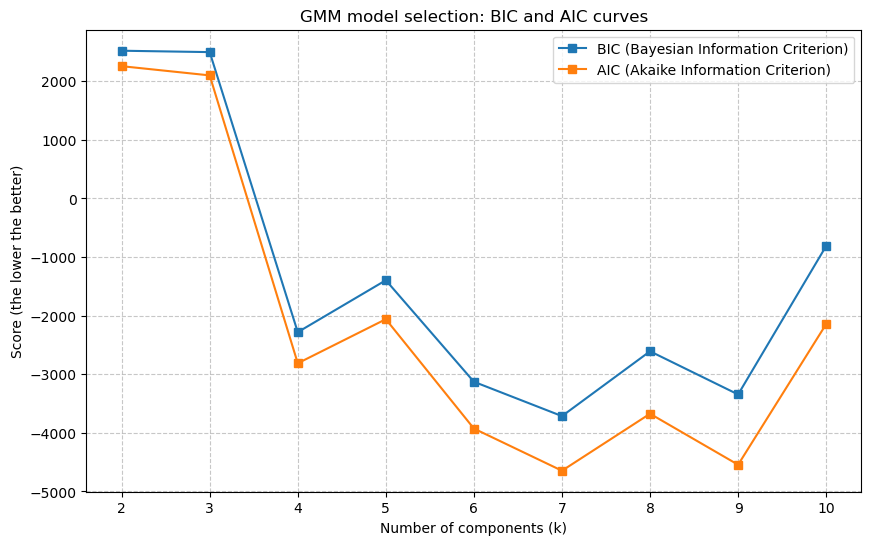

In [71]:
# Plot
plt.figure(figsize=(10,6))
plt.plot(n_components_range, bic_scores, marker = 's', label = 'BIC (Bayesian Information Criterion)')
plt.plot(n_components_range, aic_scores, marker = 's', label = 'AIC (Akaike Information Criterion)')

plt.title('GMM model selection: BIC and AIC curves')
plt.xlabel('Number of components (k)')
plt.ylabel('Score (the lower the better)')
plt.xticks(n_components_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

GMM best model:

In [72]:
# Select best k and adjust the final model
best_k = 4
gmm_best = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    init_params='random',
    random_state=42
    
)
gmm_best.fit(X_clustering)

gmm_labels = gmm_best.predict(X_clustering)
X_gmm = copy.deepcopy(X_pca)
X_gmm['GMM_Cluster'] = gmm_labels
X_gmm.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,GMM_Cluster
0,-1.561300,-2.075091,1.530980,5.361756,-2.218592,-2.291613,-1.173342,0.966294,0.631024,-0.493610,...,1.072389,-1.829736,-0.266876,0.334836,0.063249,9.815710e-16,-6.010852e-16,-1.524294e-15,-1.616698e-15,2
1,-3.067305,-1.923260,-0.750508,-1.216900,0.758253,-0.517856,-0.769176,0.573655,0.778862,-0.344092,...,0.112990,2.063077,0.622510,-0.189012,-1.161784,1.489037e-16,8.422047e-16,1.705305e-16,3.046238e-15,3
2,-3.749194,-0.046765,0.419140,-0.992844,-0.049627,0.607661,0.074765,0.133775,-0.095334,0.103313,...,0.133151,0.288637,-0.428557,0.709030,0.559402,1.906819e-16,9.814749e-19,7.635996e-16,-6.450574e-16,3
3,1.473170,0.812834,-0.550860,3.258519,-1.131793,-0.785902,3.243957,-0.982839,-0.762930,-1.282031,...,-0.575323,1.181947,0.823359,0.106861,-0.166561,6.207485e-16,1.230783e-15,3.734932e-16,2.706807e-16,1
4,2.635836,-1.300294,0.824298,-0.793962,-1.344906,-0.952969,0.047721,-0.821456,-1.085054,-0.347976,...,-0.994433,0.193442,-1.334895,-0.751734,0.882933,-2.349098e-15,-4.900629e-16,1.266876e-15,-6.174978e-16,1


### 4.3 Visualise cluster assignments by projecting the data into PCA space (2D)

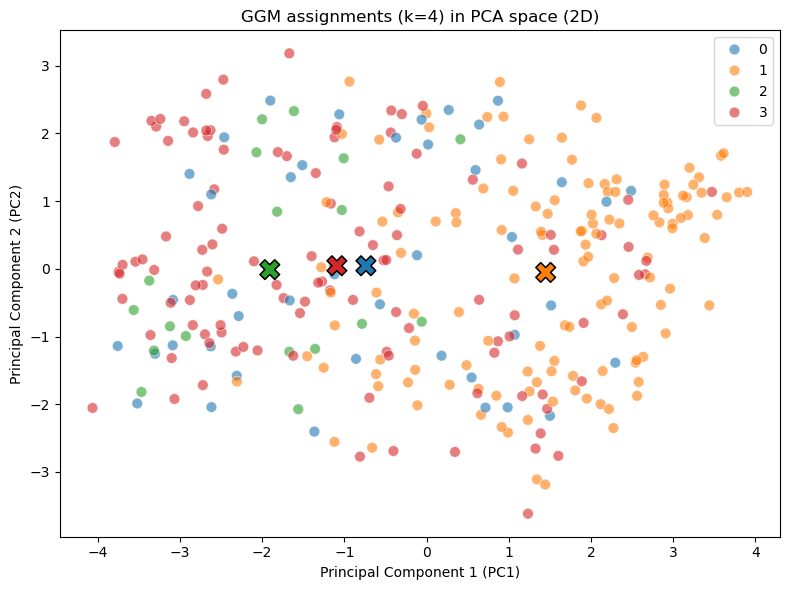

In [73]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=X_gmm,
    x="PC1",
    y="PC2",
    hue="GMM_Cluster",
    palette='tab10',
    s=60,
    alpha=0.6
)

centroids_pca = X_gmm.groupby('GMM_Cluster')[['PC1', 'PC2']].mean()

sns.scatterplot(
    data=centroids_pca,
    x="PC1",
    y="PC2",
    hue='GMM_Cluster',
    palette='tab10',
    marker="X",
    s=200,
    edgecolor='black',
    legend=False
)

plt.title(f"GGM assignments (k={best_k}) in PCA space (2D)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend()
plt.tight_layout()
plt.show()

### 4.4 Compare the hard cluster assignments from GMM with K-Means

### 4.5 Performance metrics

In [74]:
y = pd.read_csv("../data/03_selected/clustering_features_with_target.csv")['target']
truth_gmm = pd.DataFrame({
    'cluster': X_gmm['GMM_Cluster'],
    'target': y
})

ARI score:

In [75]:
ari_gmm = adjusted_rand_score(truth_gmm['cluster'], truth_gmm['target'])
print(f"Adjusted Rand Index (ARI) for GMM: {ari_gmm:.4f}")

Adjusted Rand Index (ARI) for GMM: 0.2250


Confusion Matrix:

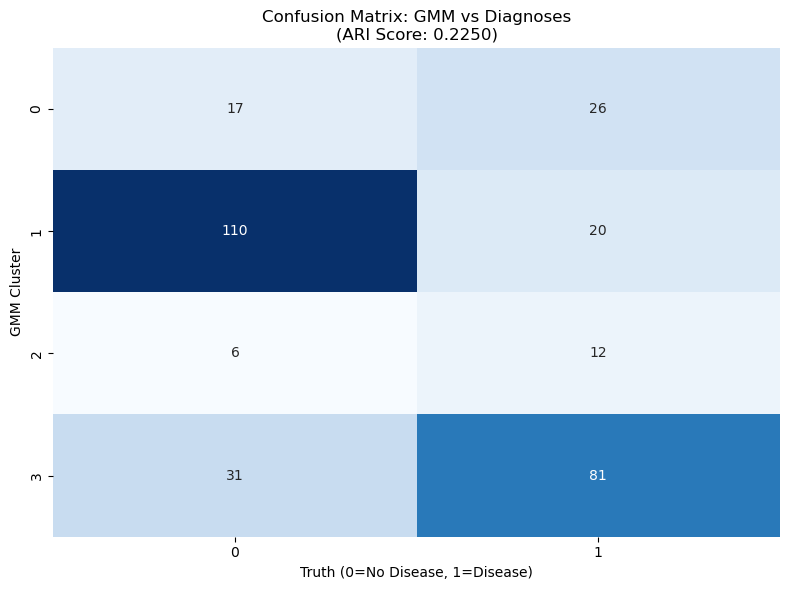

In [76]:
cm_gmm = pd.crosstab(
    index=truth_gmm['cluster'],
    columns=truth_gmm['target'],
    rownames=['GMM Cluster'],
    colnames=['Truth (0=No Disease, 1=Disease)']
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_gmm, 
    annot=True,        # Numbers in the cells
    fmt='d',           # No decimals (integers)
    cmap='Blues',
    cbar=False         # No colorbar for cleaner look
)

# Add ARI score to the title
plt.title(f'Confusion Matrix: GMM vs Diagnoses\n(ARI Score: {ari_gmm:.4f})')
plt.tight_layout()
plt.show()